In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, copy

In [2]:
data = pd.read_csv("../data/Advertising.csv")
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
data.shape

(200, 5)

In [4]:
X = data.drop("Sales", axis=1)
X.head()

,Unnamed: 0,TV,Radio,Newspaper
0,1,230.1,37.8,69.2
1,2,44.5,39.3,45.1
2,3,17.2,45.9,69.3
3,4,151.5,41.3,58.5
4,5,180.8,10.8,58.4


In [5]:
X = X.drop("Unnamed: 0", axis=1)
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [6]:
y = data.Sales
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [7]:
X = X.to_numpy()
y = y.to_numpy()

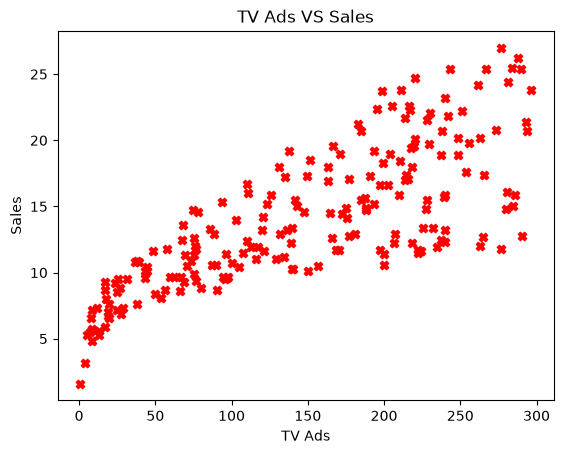

In [8]:
plt.scatter(X[:, 0], y, marker="X", c="r")
plt.xlabel("TV Ads")
plt.ylabel("Sales")
plt.title("TV Ads VS Sales")
plt.show()

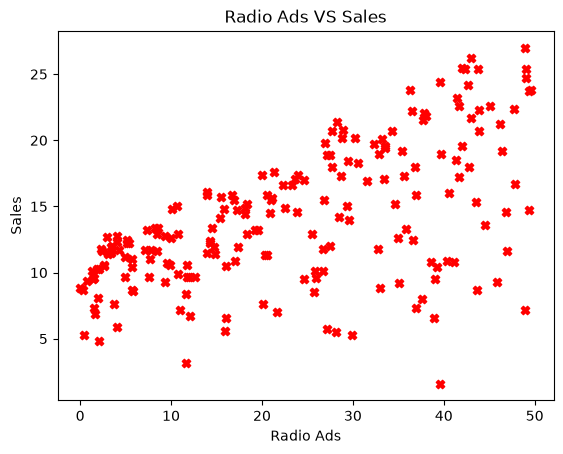

In [9]:
plt.scatter(X[:, 1], y, marker="X", c="r")
plt.xlabel("Radio Ads")
plt.ylabel("Sales")
plt.title("Radio Ads VS Sales")
plt.show()

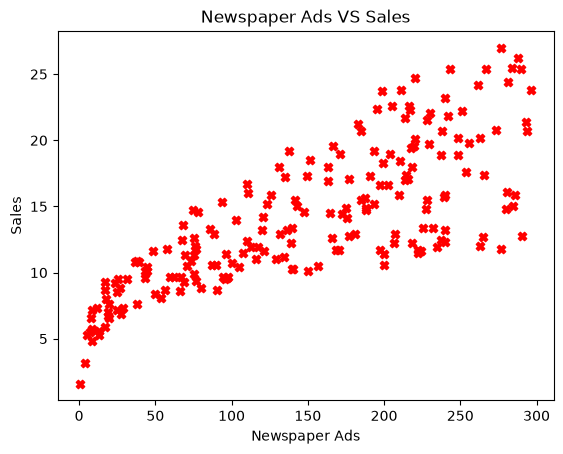

In [10]:
plt.scatter(X[:, 0], y, marker="X", c="r")
plt.xlabel("Newspaper Ads")
plt.ylabel("Sales")
plt.title("Newspaper Ads VS Sales")
plt.show()

<Axes: >

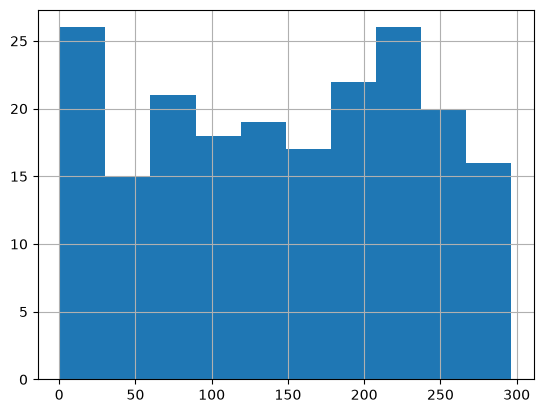

In [11]:
data["TV"].hist()

<Axes: >

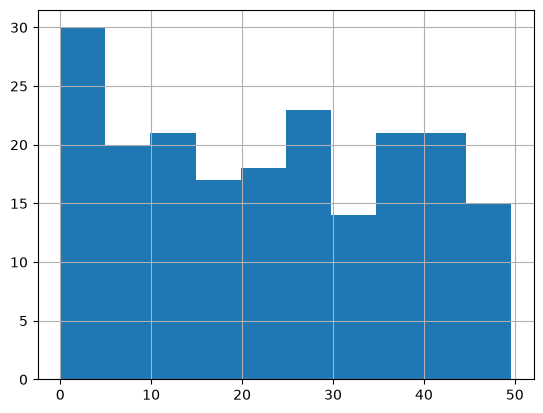

In [12]:
data["Radio"].hist()

<Axes: >

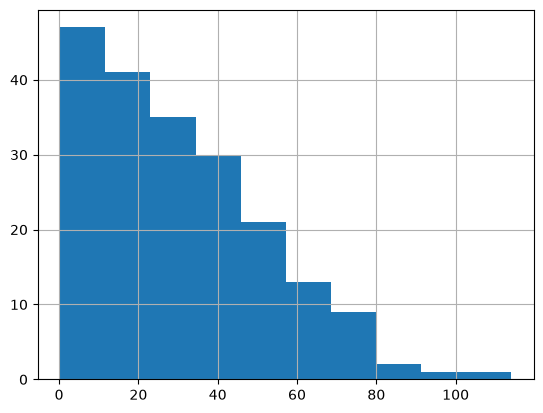

In [13]:
data["Newspaper"].hist()

In [14]:
data = data.drop("Unnamed: 0", axis=1)

In [15]:
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [16]:
correlation_matrix = data.corr()

In [17]:
correlation_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


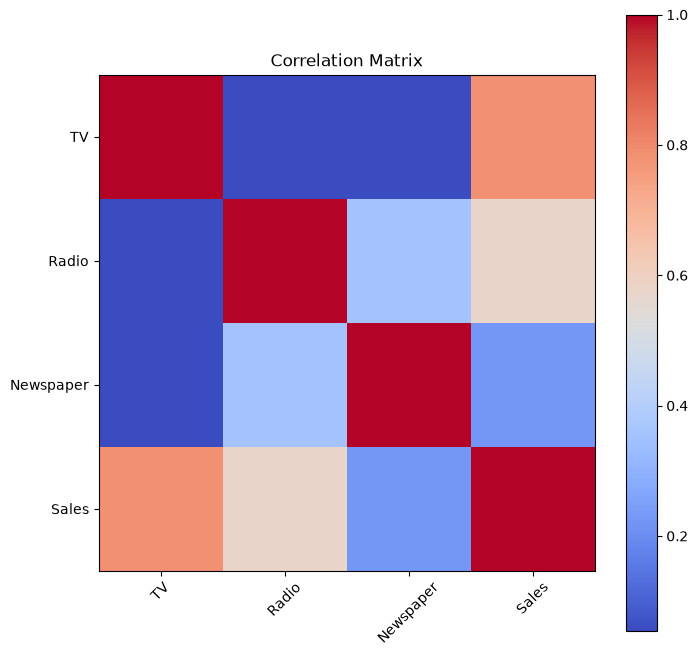

In [18]:
plt.figure(figsize=(8, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="None")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix")
plt.show()

In [19]:
def compute_fwb(X, w, b):
    return np.dot(X, w)+b

In [20]:
w_init = np.array([1, 1, 1])
b_init = 10
X_vec = X[0, : ]
fwb = compute_fwb(X_vec, w_init, b_init)
print(fwb)

347.09999999999997


In [30]:
def compute_cost(X, y, w, b):
    r, c = X.shape
    cost = 0
    for i in range(r):
        fwb = np.dot(X[i], w)+b
        cost += (fwb - y[i])**2

    return cost/(2*r)

In [31]:
cost = compute_cost(X, y, w_init, b_init)
print(f'Cost at w : {cost}')

Cost at w : 23268.78584999999


In [32]:
def compute_gradient(X, y, w, b):
    dj_dw = np.zeros_like(w, dtype=np.float64)
    dj_db = 0.0

    m = X.shape[0]

    for i in range(m):
        fwb = np.dot(X[i], w)+b
        error = fwb - y[i]

        dj_dw += error*X[i]
        dj_db += error

    return dj_dw/m, dj_db/m



In [33]:
print(compute_gradient(X, y, w_init, b_init))

(array([36103.91155,  4937.59   ,  6679.6277 ]), np.float64(196.8379999999999))


In [36]:
def gradient_descent(X, y, w_in, b_in, alpha, cost_function, gradiant_function, num_iter=10000, tolerance=1e-6):

    w = w_in
    b = b_in

    p_hist = []
    j_hist = []

    c1, c2 = 0, 0

    for i in range(num_iter):
        dj_dw, dj_db = gradiant_function(X, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        cost = cost_function(X, y, w, b)

        c2 = c1
        c1 = cost

        j_hist.append(cost)
        p_hist.append([w, b])

        if i % math.ceil(num_iter / 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_hist[-1]:8.2f}")

        if abs(c2 - c1) < tolerance:
            break

    return w, b, p_hist, j_hist

In [55]:
w_inp = np.zeros(X.shape[1], dtype=np.float64)
b_inp = 0.0

num_iter = 1000000
alpha = 1e-7

w_final, b_final, p_hist, j_hist = gradient_descent(X, y, w_inp, b_inp, alpha, compute_cost, compute_gradient, num_iter)

Iteration    0: Cost   111.24


In [56]:
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X.shape
for i in range(m):
    print(f"prediction: {np.dot(X[i], w_final) + b_final:0.2f}, target value: {y[i]}")

b,w found by gradient descent: 0.01,[0.05486713 0.18949264 0.03474505] 
prediction: 22.20, target value: 22.1
prediction: 11.46, target value: 10.4
prediction: 12.06, target value: 9.3
prediction: 18.18, target value: 18.5
prediction: 14.00, target value: 12.9
prediction: 12.36, target value: 7.2
prediction: 10.19, target value: 11.8
prediction: 10.72, target value: 13.2
prediction: 0.91, target value: 4.8
prediction: 12.20, target value: 10.6
prediction: 5.57, target value: 8.6
prediction: 16.47, target value: 17.4
prediction: 10.25, target value: 9.2
prediction: 7.05, target value: 9.7
prediction: 19.04, target value: 19.0
prediction: 21.60, target value: 22.4
prediction: 14.62, target value: 12.5
prediction: 24.89, target value: 24.4
prediction: 8.32, target value: 11.3
prediction: 13.28, target value: 14.6
prediction: 19.09, target value: 18.0
prediction: 14.81, target value: 12.5
prediction: 5.47, target value: 5.6
prediction: 16.65, target value: 15.5
prediction: 6.45, target val

In [58]:
def predict_sales():
    tv = float(input("Enter TV advertising budget: "))
    radio = float(input("Enter Radio advertising budget: "))
    newspaper = float(input("Enter Newspaper advertising budget: "))

    features = np.array([[tv, radio, newspaper]])
    prediction = np.dot(features, w_final) + b_final

    print(f"Predicted sales: {prediction[0]:.2f}")
    return prediction[0]


predict_sales()

Predicted sales: 10.25


np.float64(10.252884388948667)